# Sample-size stability and repeatability

Supporting notebook for the manuscript subsection **Sample-size stability and repeatability**.

This is intentionally the long-running benchmark notebook. It evaluates simple random sampling and independently scrambled Sobol QMC sampling across nine models and ten repetitions. The package minimum of **100 observations per region** is respected; estimates that do not satisfy that requirement are recorded as unavailable rather than replaced by zero.

In [1]:
!pip install simdec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 25.8 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import qmc
from IPython.display import display


import json
from importlib.metadata import distribution, version

import simdec as sd

assert callable(getattr(sd, "sensitivity_indices", None))
assert callable(getattr(sd, "heterogeneity_indices", None))

dist = distribution("simdec")
print("SimDec version:", version("simdec"))
print("SimDec module:", sd.__file__)

direct_url = dist.read_text("direct_url.json")
if direct_url:
    print("Installation provenance:")
    print(json.dumps(json.loads(direct_url), indent=2))
else:
    print("No direct_url.json was found for this installation.")


N_TARGETS = [100, 1_000, 10_000, 100_000]
N_REPEATS = 10
N_REGIONS = 5
MASTER_SEED = 20260910
OUTPUT_DIR = Path("section_03_sample_size")
OUTPUT_DIR.mkdir(exist_ok=True)
METHODS = ["MC", "QMC"]
METHOD_LABELS = {"MC": "Simple random sampling", "QMC": "Scrambled Sobol QMC"}

CMAP = plt.colormaps["terrain"]
VARIABLE_COLORS = {f"X{i}": CMAP(t) for i, t in enumerate(np.linspace(0.05, 0.85, 6), start=1)}
VARIABLE_COLORS["Y"] = "#333333"
VARIABLE_MARKERS = dict(zip(["Y", "X1", "X2", "X3", "X4", "X5", "X6"], ["o", "s", "^", "D", "v", "P", "X"]))

def variable_label(name):
    return "$Y$" if name == "Y" else rf"$X_{{{name[1:]}}}$"

def nearest_power_of_two(n):
    lower = 1 << (int(n).bit_length() - 1)
    upper = 2 * lower
    return lower if n - lower < upper - n else upper

sample_plan = pd.DataFrame([{"N_target": n, "N_MC": n, "N_QMC": nearest_power_of_two(n)} for n in N_TARGETS])
display(sample_plan)

SimDec version: 1.5.2
SimDec module: /usr/local/lib/python3.13/dist-packages/simdec/__init__.py
No direct_url.json was found for this installation.


,N_target,N_MC,N_QMC
0,100,100,128
1,1000,1000,1024
2,10000,10000,8192
3,100000,100000,131072


In [3]:
import importlib
from contextlib import contextmanager

hi = importlib.import_module("simdec.heterogeneity_indices")


@contextmanager
def temporary_min_region_size(n):
    original = hi._MIN_REGION_SIZE
    hi._MIN_REGION_SIZE = n
    try:
        yield
    finally:
        hi._MIN_REGION_SIZE = original

In [4]:
# Benchmark definitions used in Sections 2--4.
def binary_model(x):
    # X1=A, X2=K, X3=B; a=4.
    return x[:, 0] + (1 + 4 * x[:, 1]) * x[:, 2]


def f1(x):
    return 10 * x[:, 0] + 0.5 * x[:, 1] ** 3


def f2(x):
    return 2 * x[:, 0] - x[:, 1] ** 2


def f3(x):
    x1, x2, x3 = x.T
    return x1**2 + x2**4 + x1 * x2 + x2 * x3**4


def f4(x):
    x1, x2 = x.T
    return (
        0.2 * np.exp(x1 - 3)
        + 2.2 * np.abs(x2)
        + 1.3 * x2**6
        - 2 * x2**2
        - 0.5 * x2**4
        - 0.5 * x1**4
        + 2.5 * x1**2
        + 0.7 * x1**3
        + 3 / ((8 * x1 - 2) ** 2 + (5 * x2 - 3) ** 2 + 1)
        + np.sin(5 * x1) * np.cos(3 * x1**2)
    )


def ishigami(x):
    x1, x2, x3 = x.T
    return np.sin(x1) + 7 * np.sin(x2) ** 2 + 0.1 * x3**4 * np.sin(x1)


def hartmann6(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    a = np.array([
        [10, 3, 17, 3.50, 1.7, 8],
        [0.05, 10, 17, 0.1, 8, 14],
        [3, 3.5, 1.7, 10, 17, 8],
        [17, 8, 0.05, 10, 0.1, 14],
    ])
    p = 1e-4 * np.array([
        [1312, 1696, 5569, 124, 8283, 5886],
        [2329, 4135, 8307, 3736, 1004, 9991],
        [2348, 1451, 3522, 2883, 3047, 6650],
        [4047, 8828, 8732, 5743, 1091, 381],
    ])
    exponent = -np.sum(a[None, :, :] * (x[:, None, :] - p[None, :, :]) ** 2, axis=2)
    return -np.sum(alpha[None, :] * np.exp(exponent), axis=1)


def kriging(x):
    x1, x2, x3, x4 = x.T
    return (
        1
        + np.exp(-2 * ((x1 - 1) ** 2 + x2**2) - 0.5 * (x3**2 + x4**2))
        + np.exp(-2 * (x1**2 + (x2 - 1) ** 2) - 0.5 * (x3**2 + x4**2))
    )


def owen(x):
    tau = np.array([1, 1, 0.5, 0.5, 0.25, 0.25])
    return np.prod(1 + tau * np.sqrt(12) * (x - 0.5), axis=1)


F4_BOUNDS = (-1.0, 1.0)
BENCHMARKS = {
    "Binary": {"function": binary_model, "d": 3, "bounds": (0, 1), "binary_col": 1},
    "F1": {"function": f1, "d": 2, "bounds": (-5, 5)},
    "F2": {"function": f2, "d": 2, "bounds": (-5, 5)},
    "F3": {"function": f3, "d": 3, "bounds": (-4, 4)},
    "F4": {"function": f4, "d": 2, "bounds": F4_BOUNDS},
    "Ishigami": {"function": ishigami, "d": 3, "bounds": (-np.pi, np.pi)},
    "Hartmann 6-D": {"function": hartmann6, "d": 6, "bounds": (0, 1)},
    "Kriging": {"function": kriging, "d": 4, "bounds": (0, 1)},
    "Owen": {"function": owen, "d": 6, "bounds": (0, 1)},
}
FUNCTION_NAMES = list(BENCHMARKS)
FUNCTION_TITLES = {name: name for name in FUNCTION_NAMES}
FUNCTION_TITLES["Binary"] = "Binary model ($a=4$)"

In [5]:
def simulation_sample(name, method, n, repeat):
    spec = BENCHMARKS[name]
    entropy = [FUNCTION_NAMES.index(name), METHODS.index(method), int(n), int(repeat), MASTER_SEED]
    rng = np.random.default_rng(np.random.SeedSequence(entropy))
    if method == "MC":
        u = rng.random((int(n), spec["d"]))
    else:
        if int(n) & (int(n) - 1):
            raise ValueError("QMC sample size must be a power of two.")
        engine = qmc.Sobol(d=spec["d"], scramble=True, seed=rng)
        u = engine.random_base2(int(n).bit_length() - 1)
    low, high = spec["bounds"]
    x = low + (high - low) * u
    if "binary_col" in spec:
        j = spec["binary_col"]
        x[:, j] = (u[:, j] >= 0.5).astype(int)
    X = pd.DataFrame(x, columns=[f"X{i+1}" for i in range(spec["d"])])
    y = pd.Series(spec["function"](x), name="Y")
    return X, y


def evaluate_dataset(name, method, n, n_target, repeat):
    X, y = simulation_sample(name, method, n, repeat)
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        H = sd.heterogeneity_indices(output=y, inputs=X, n_regions=N_REGIONS)
    warning_text = " | ".join(sorted({f"{w.category.__name__}: {w.message}" for w in caught}))
    rows = []
    for variable in ["Y", *X.columns]:
        value = float(H.indices.get(variable, np.nan))
        detail = H.details.get(variable)
        rows.append({
            "function": name,
            "method": method,
            "N_target": int(n_target),
            "N": int(n),
            "repeat": int(repeat),
            "variable": variable,
            "H": value,
            "valid": bool(np.isfinite(value)),
            "region_n_min": np.nan if detail is None else int(detail.region_counts.min()),
            "region_n_max": np.nan if detail is None else int(detail.region_counts.max()),
            "raw_sum_min": np.nan if detail is None else float(detail.regional_sums.min()),
            "raw_sum_max": np.nan if detail is None else float(detail.regional_sums.max()),
            "warnings": warning_text,
            "elapsed_seconds_dataset": time.perf_counter() - started,
        })
    return rows

In [6]:
# Main computation. This cell is intentionally long-running.
with temporary_min_region_size(10):
  records = []
  for function_name in FUNCTION_NAMES:
      for method in METHODS:
          for plan in sample_plan.to_dict("records"):
              n = int(plan[f"N_{method}"])
              for repeat in range(N_REPEATS):
                  records.extend(evaluate_dataset(function_name, method, n, plan["N_target"], repeat))
          print(f"{function_name} / {method}: finished")

  results = pd.DataFrame(records)
  results.to_csv(OUTPUT_DIR / "sample_size_results.csv", index=False)
  print("Valid estimates:", int(results["valid"].sum()), "/", len(results))
  display(results.loc[~results["valid"], ["function", "method", "N", "repeat", "variable", "warnings"]].head(20))

Binary / MC: finished
Binary / QMC: finished
F1 / MC: finished
F1 / QMC: finished
F2 / MC: finished
F2 / QMC: finished
F3 / MC: finished
F3 / QMC: finished
F4 / MC: finished
F4 / QMC: finished
Ishigami / MC: finished
Ishigami / QMC: finished
Hartmann 6-D / MC: finished
Hartmann 6-D / QMC: finished
Kriging / MC: finished
Kriging / QMC: finished
Owen / MC: finished
Owen / QMC: finished
Valid estimates: 3200 / 3200


,function,method,N,repeat,variable,warnings


In [7]:
GROUP = ["function", "method", "N_target", "N", "variable"]
summary = (
    results.groupby(GROUP, as_index=False)
    .agg(
        valid_count=("valid", "sum"),
        mean_H=("H", "mean"),
        median_H=("H", "median"),
        sd_H=("H", lambda x: x.dropna().std(ddof=1)),
        min_H=("H", "min"),
        max_H=("H", "max"),
    )
)
summary.to_csv(OUTPUT_DIR / "sample_size_summary.csv", index=False)
display(summary.head())

binary_check = summary.loc[(summary["function"] == "Binary") & (summary["variable"] == "X2")]
print("Analytical reference for Binary X2=K:", 6/13)
display(binary_check)

,function,method,N_target,N,variable,valid_count,mean_H,median_H,sd_H,min_H,max_H
0,Binary,MC,100,100,X1,10,0.110604,0.116750,0.025611,0.061546,0.148047
1,Binary,MC,100,100,X2,10,0.090312,0.106454,0.055231,0.005856,0.162873
2,Binary,MC,100,100,X3,10,0.148729,0.126961,0.039625,0.109291,0.217598
3,Binary,MC,100,100,Y,10,0.186882,0.176956,0.036120,0.150663,0.264887
4,Binary,MC,1000,1000,X1,10,0.051974,0.056560,0.018307,0.016419,0.072112


Analytical reference for Binary X2=K: 0.46153846153846156


,function,method,N_target,N,variable,valid_count,mean_H,median_H,sd_H,min_H,max_H
1,Binary,MC,100,100,X2,10,0.090312,0.106454,0.055231,0.005856,0.162873
5,Binary,MC,1000,1000,X2,10,0.408240,0.407260,0.016282,0.390522,0.442323
9,Binary,MC,10000,10000,X2,10,0.457153,0.456334,0.004383,0.451935,0.464711
13,Binary,MC,100000,100000,X2,10,0.459751,0.459424,0.001625,0.457460,0.462687
17,Binary,QMC,100,128,X2,10,0.170083,0.160240,0.068684,0.075909,0.292413
21,Binary,QMC,1000,1024,X2,10,0.461151,0.461345,0.000845,0.459339,0.462431
25,Binary,QMC,10000,8192,X2,10,0.461360,0.461360,0.000132,0.461122,0.461562
29,Binary,QMC,100000,131072,X2,10,0.461533,0.461532,0.000005,0.461525,0.461539


## Figure 5 & Appendix 2. Sample-size stability of the heterogeneity index

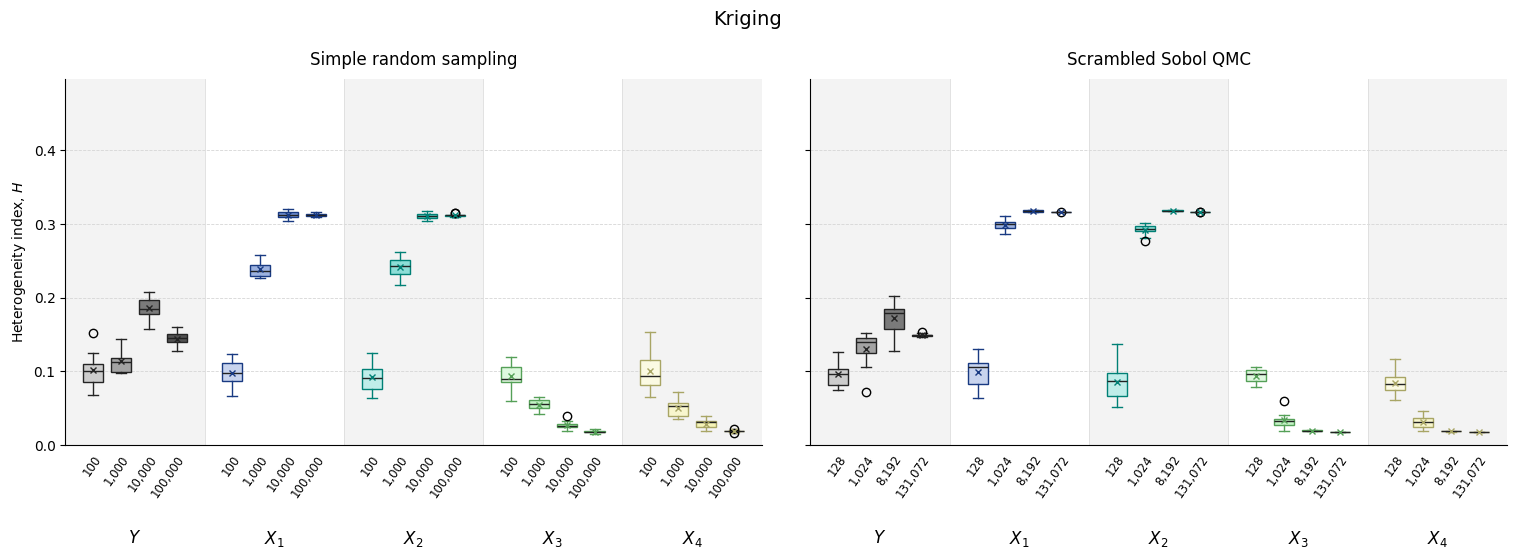

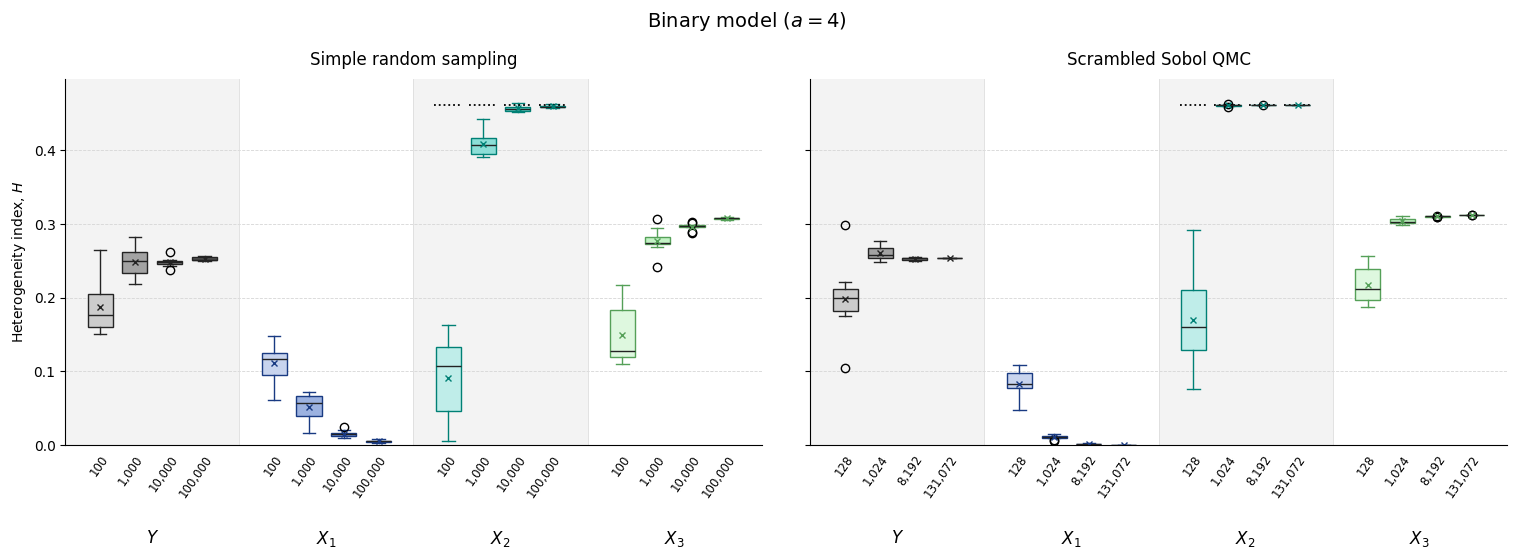

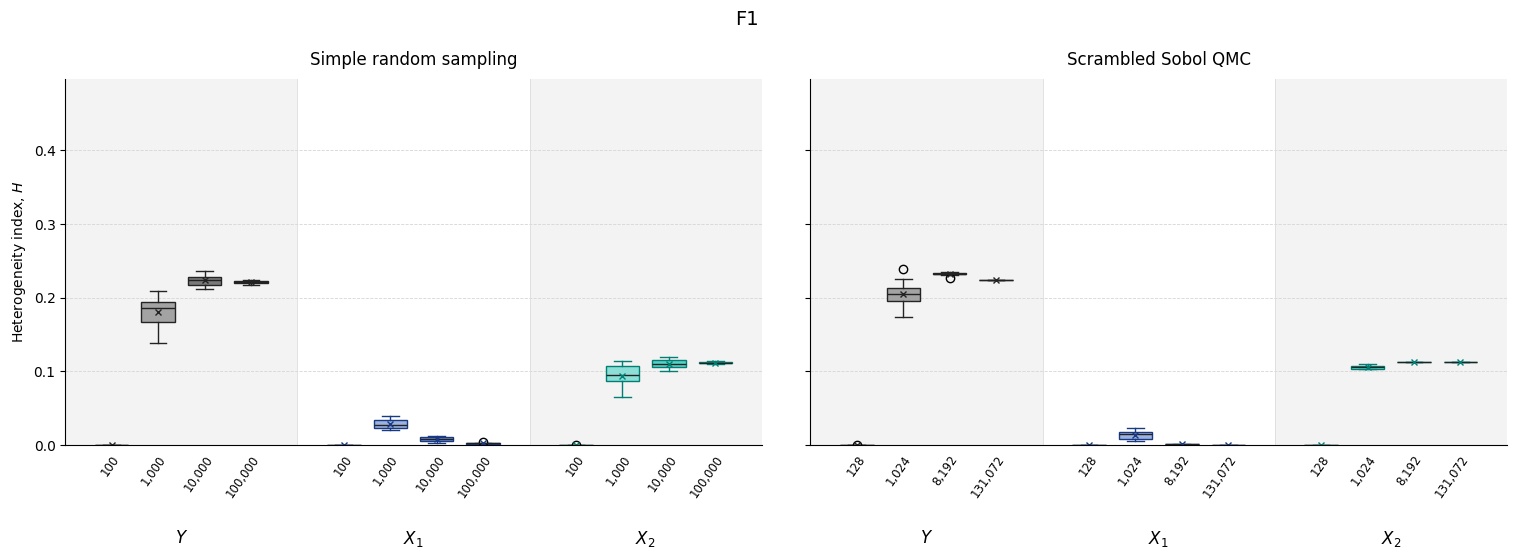

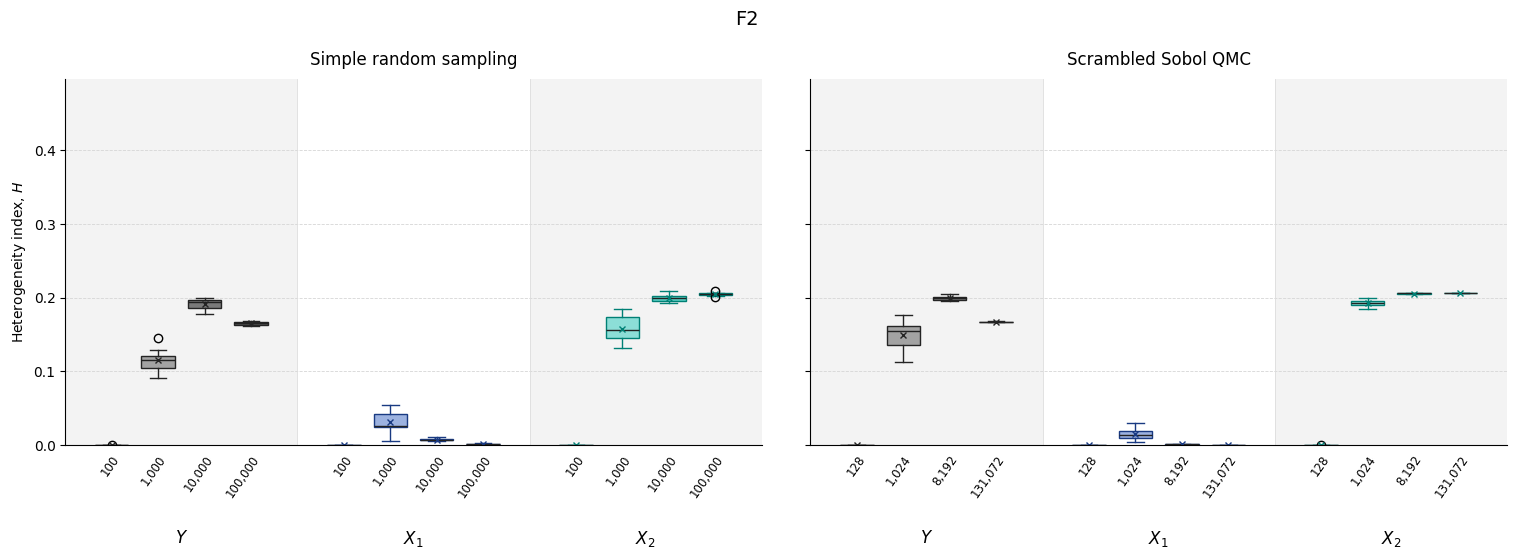

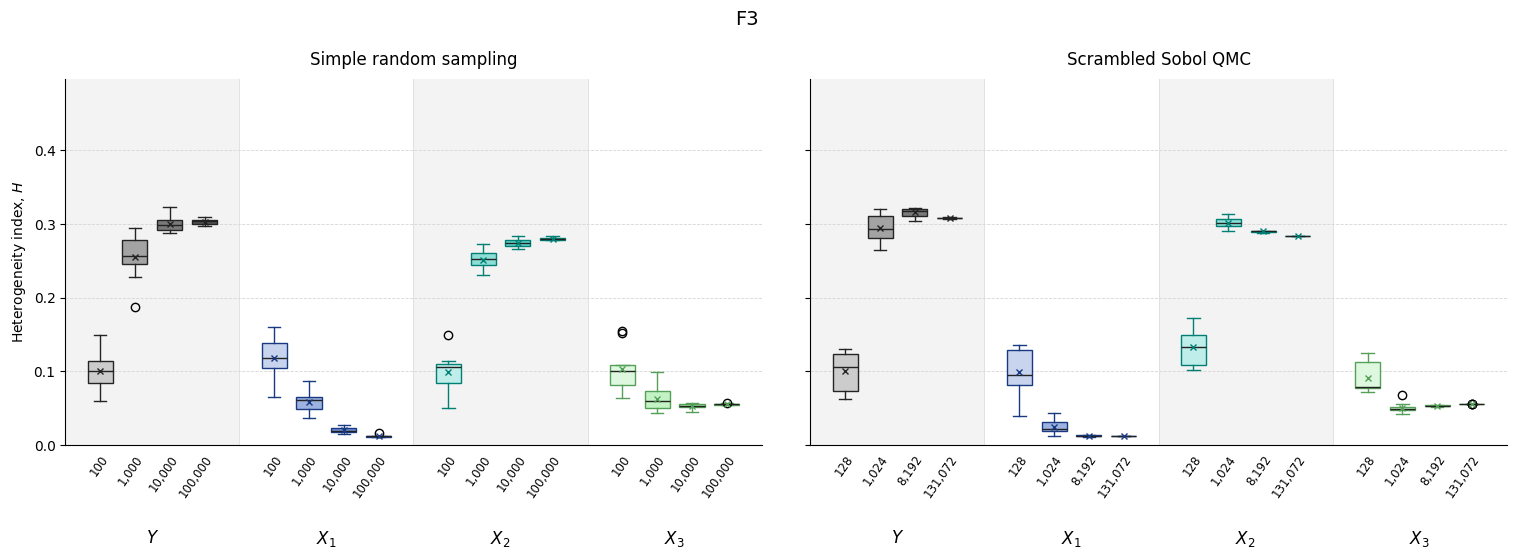

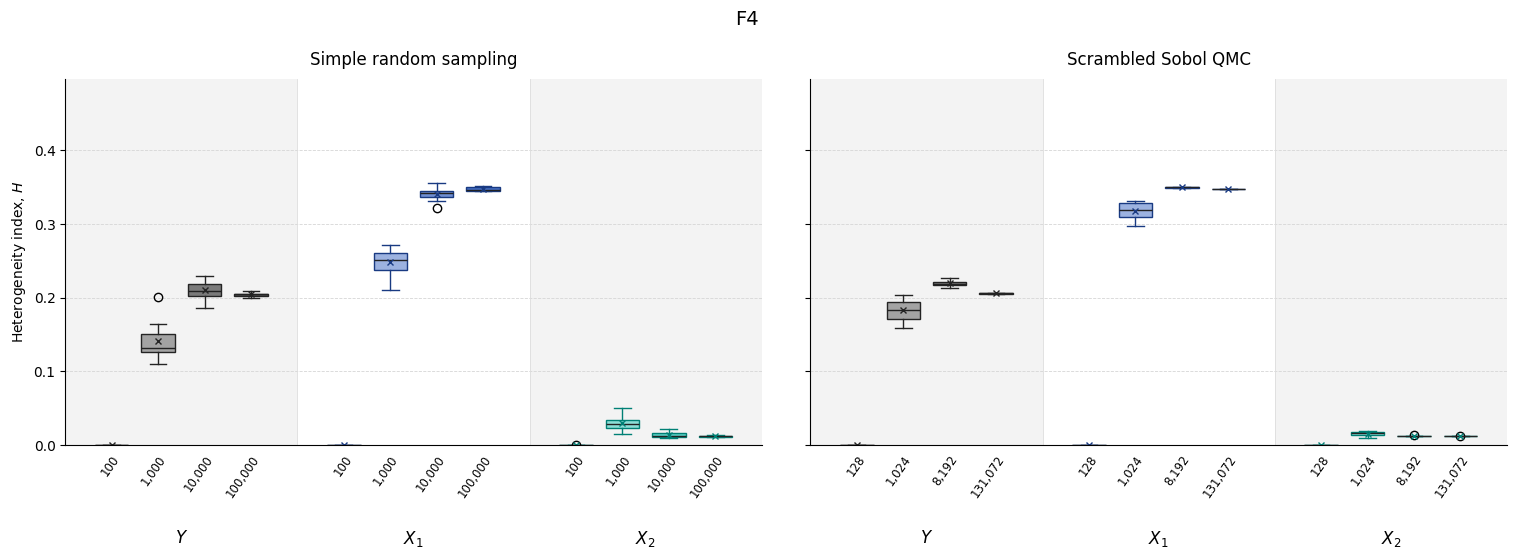

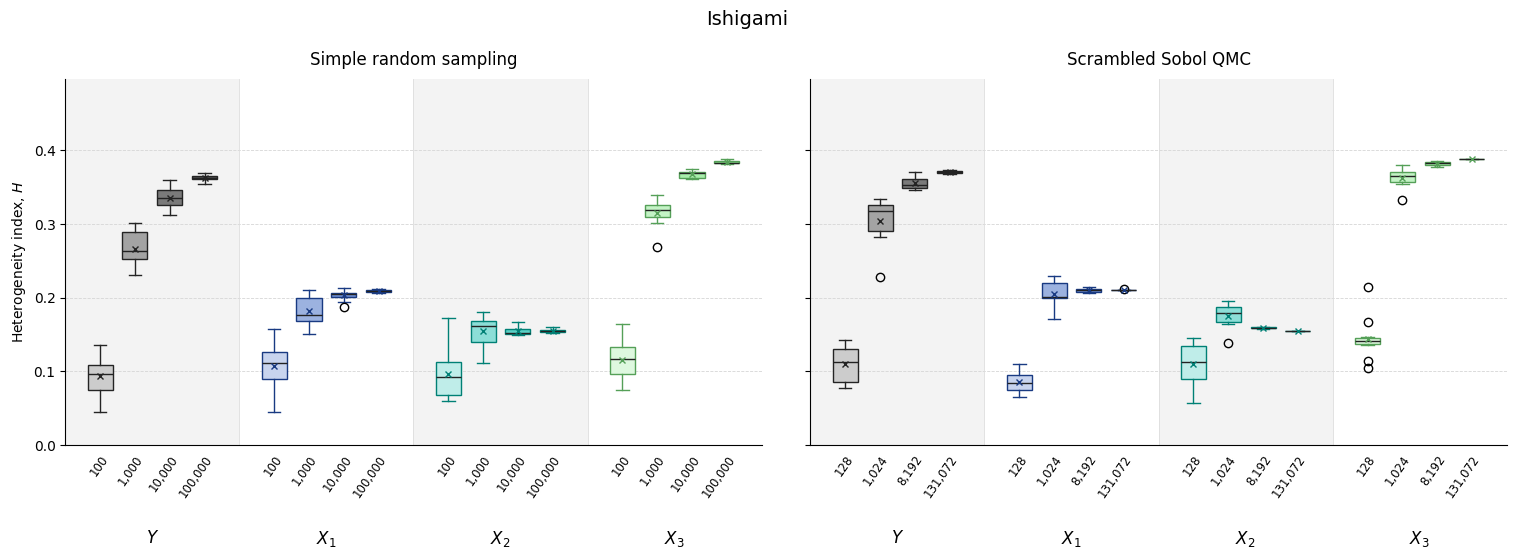

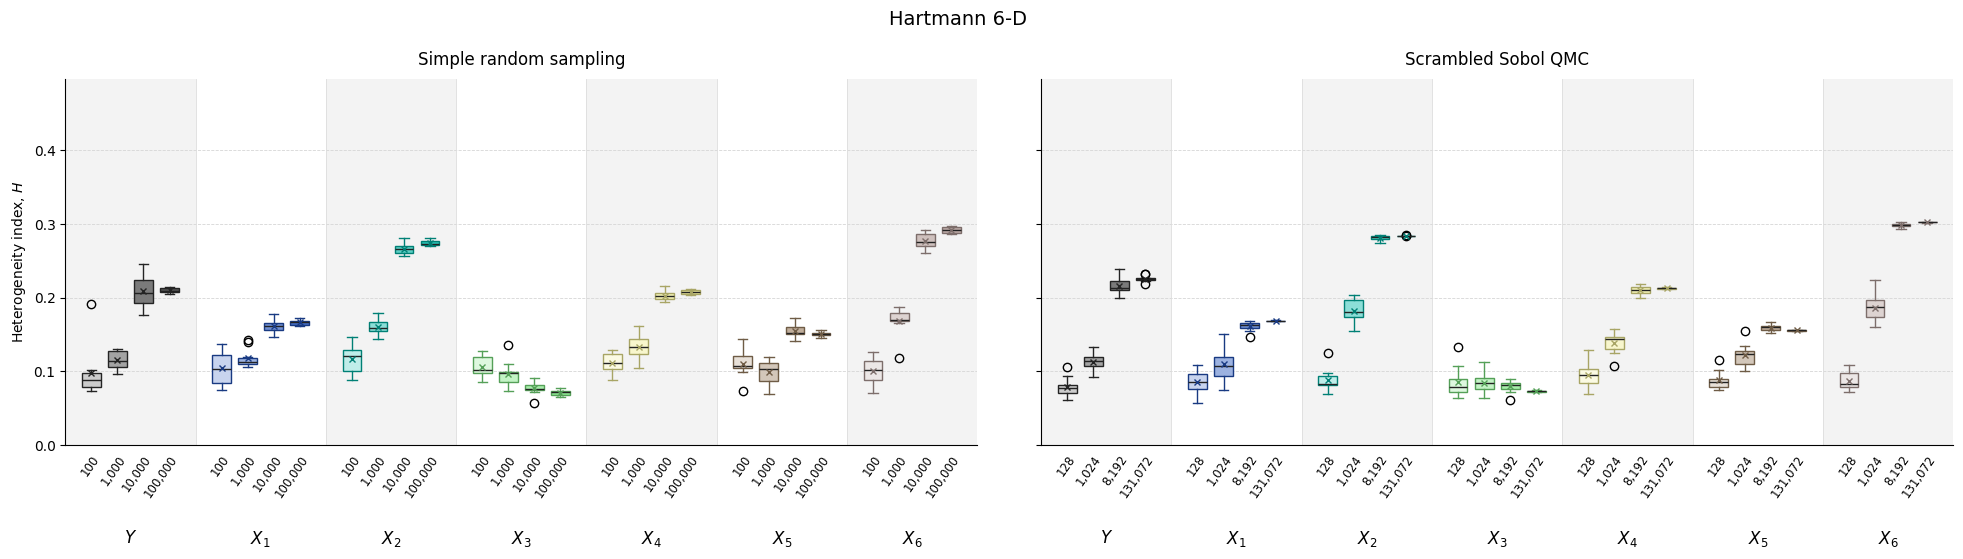

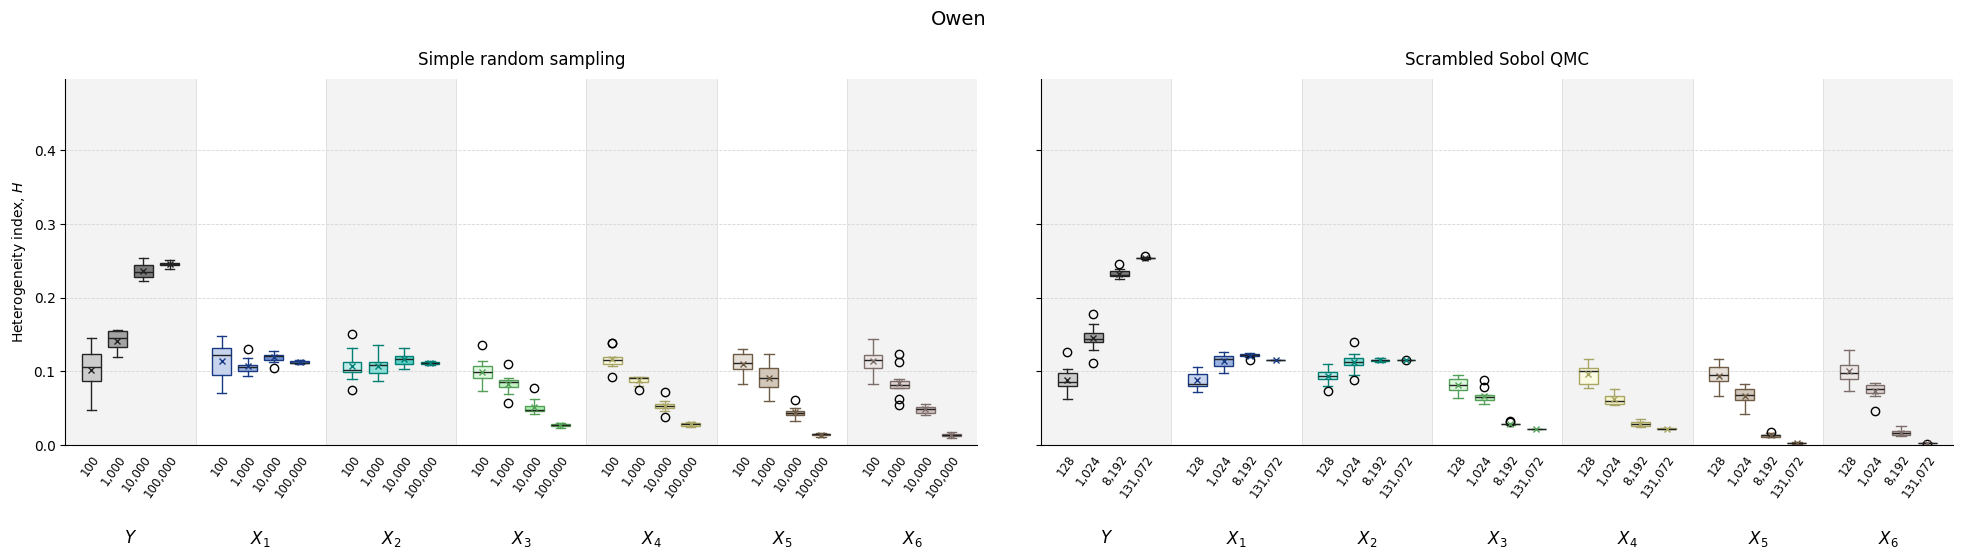

In [8]:
def plot_sample_size_boxes(function_name, filename=None):
    from matplotlib.colors import to_rgb
    data = results.loc[results["function"] == function_name].copy()
    variables = ["Y", *[f"X{i+1}" for i in range(BENCHMARKS[function_name]["d"])]]
    plans = sample_plan.sort_values("N_target").to_dict("records")
    centers = np.arange(len(variables), dtype=float)
    slot_width = 0.80 / len(plans)
    offsets = (np.arange(len(plans)) - (len(plans) - 1) / 2) * slot_width
    box_width = 0.72 * slot_width
    strengths = np.linspace(0.25, 0.85, len(plans))
    base_colors = {v: np.array(to_rgb(VARIABLE_COLORS[v])) for v in variables}
    edge_colors = {v: 0.70 * base_colors[v] for v in variables}

    valid_all = results.loc[results["valid"], "H"].dropna()
    ymax = max(0.05, valid_all.max() * 1.07) if len(valid_all) else 1.0
    fig, axes = plt.subplots(1, 2, figsize=(max(15.5, 2.9 * len(variables)), 6.0), sharey=True)

    for ax, method in zip(axes, METHODS):
        tick_positions, tick_labels = [], []
        for group_i, (center, variable) in enumerate(zip(centers, variables)):
            if group_i % 2 == 0:
                ax.axvspan(center - 0.5, center + 0.5, color="#f3f3f3", linewidth=0, zorder=0)
            if group_i:
                ax.axvline(center - 0.5, color="#dddddd", linewidth=0.6)
            for offset, plan, strength in zip(offsets, plans, strengths):
                pos = center + offset
                n = int(plan[f"N_{method}"])
                tick_positions.append(pos)
                tick_labels.append(f"{n:,}")
                block = data.loc[(data["method"] == method) & (data["N_target"] == plan["N_target"]) & (data["variable"] == variable)]
                vals = block.loc[block["valid"], "H"].dropna().to_numpy(float)
                if len(vals):
                    face = (1 - strength) + strength * base_colors[variable]
                    ax.boxplot([vals], positions=[pos], widths=box_width, patch_artist=True, manage_ticks=False, showmeans=True,
                               boxprops={"facecolor": face, "edgecolor": edge_colors[variable]},
                               medianprops={"color": "#222222"},
                               whiskerprops={"color": edge_colors[variable]}, capprops={"color": edge_colors[variable]},
                               meanprops={"marker": "x", "markersize": 4, "markeredgecolor": edge_colors[variable], "markerfacecolor": "none"})
                if function_name == "Binary" and variable == "X2":
                    ax.hlines(6/13, pos - 0.55*box_width, pos + 0.55*box_width, color="black", linestyle=":", linewidth=1.3)
            ax.text(center, -0.23, variable_label(variable), transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=12, clip_on=False)

        ax.set_title(METHOD_LABELS[method], fontsize=12, pad=10)
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=8.5, rotation=55, ha="right", rotation_mode="anchor")
        ax.set_xlim(-0.5, len(variables) - 0.5)
        ax.set_ylim(0, ymax)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, color="#d6d6d6")
        ax.tick_params(axis="x", length=0, pad=6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[0].set_ylabel(r"Heterogeneity index, $H$")
    fig.suptitle(FUNCTION_TITLES[function_name], fontsize=14, y=0.985)
    fig.subplots_adjust(left=0.06, right=0.99, bottom=0.26, top=0.87, wspace=0.07)
    plt.show()

# Manuscript Figure h4.
plot_sample_size_boxes("Kriging", filename="h4")

# Appendix equivalents.
for name in FUNCTION_NAMES:
    if name != "Kriging":
        stem = name.lower().replace(" ", "_").replace("-", "_")
        plot_sample_size_boxes(name, filename=str(OUTPUT_DIR / f"appendix_boxes_{stem}"))

## Figure 6

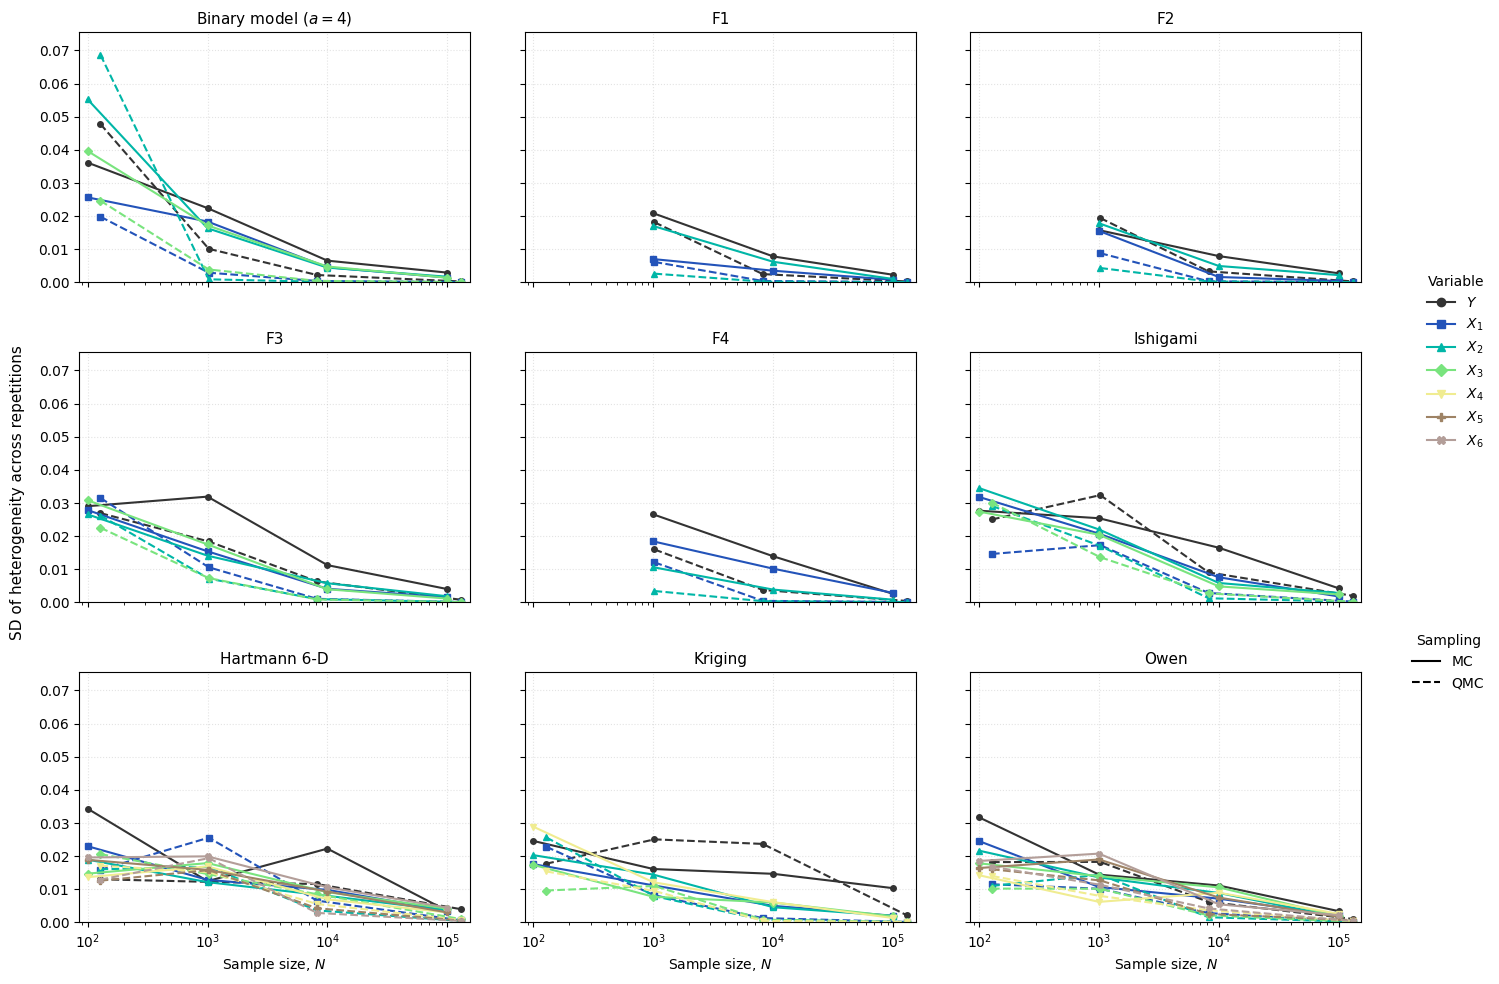

In [9]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 10),
    sharex=True,
    sharey=True,
)

styles = {"MC": "-", "QMC": "--"}
skip_smallest = {"F1", "F2", "F4"}

# Determine y-axis limit using only the points that will actually be plotted.
sd_values = []

for name in FUNCTION_NAMES:
    d = BENCHMARKS[name]["d"]

    for variable in ["Y", *[f"X{i+1}" for i in range(d)]]:
        for method in METHODS:
            frame = summary.loc[
                (summary["function"] == name)
                & (summary["variable"] == variable)
                & (summary["method"] == method)
            ].sort_values("N")

            if name in skip_smallest:
                frame = frame.iloc[1:]

            sd_values.extend(frame["sd_H"].dropna().tolist())

ymax = max(1e-6, max(sd_values) * 1.10) if sd_values else 1.0

all_n = summary["N"].dropna().to_numpy(float)
xmin, xmax = all_n.min() / 1.18, all_n.max() * 1.18

for ax, name in zip(axes.flat, FUNCTION_NAMES):
    d = BENCHMARKS[name]["d"]

    for variable in ["Y", *[f"X{i+1}" for i in range(d)]]:
        for method in METHODS:
            frame = summary.loc[
                (summary["function"] == name)
                & (summary["variable"] == variable)
                & (summary["method"] == method)
            ].sort_values("N")

            # Omit deliberately degenerate smallest-sample estimates
            # for F1, F2, and F4.
            if name in skip_smallest:
                frame = frame.iloc[1:]

            ax.plot(
                frame["N"],
                frame["sd_H"],
                color=VARIABLE_COLORS[variable],
                marker=VARIABLE_MARKERS[variable],
                linestyle=styles[method],
                linewidth=1.5,
                markersize=4,
            )

    ax.set_title(FUNCTION_TITLES[name], fontsize=11)
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, ymax)
    ax.grid(linestyle=":", alpha=0.35)

for ax in axes[-1, :]:
    ax.set_xlabel("Sample size, $N$")

fig.supylabel(
    "SD of heterogeneity across repetitions",
    x=0.009,
    fontsize=11,
)

var_handles = [
    Line2D(
        [0], [0],
        color=VARIABLE_COLORS[v],
        marker=VARIABLE_MARKERS[v],
        label=variable_label(v),
    )
    for v in ["Y", "X1", "X2", "X3", "X4", "X5", "X6"]
]

method_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=styles[m],
        label=m,
    )
    for m in METHODS
]

fig.legend(
    handles=var_handles,
    title="Variable",
    loc="center right",
    bbox_to_anchor=(1.0, 0.63),
    frameon=False,
)

fig.legend(
    handles=method_handles,
    title="Sampling",
    loc="center right",
    bbox_to_anchor=(1.0, 0.33),
    frameon=False,
)

fig.subplots_adjust(
    left=0.055,
    right=0.91,
    bottom=0.07,
    top=0.96,
    wspace=0.14,
    hspace=0.28,
)

plt.show()

Figure 6: Sample size and strategy effects on the heterogeneity index 𝐻 across all nine test functions.